In [1]:
%pip install -r requirements.txt

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


valid lines [1, 2, 3, 4, 0, 5]
[[np.int64(3), np.int64(0)], [np.int64(1), np.int64(2)], [np.int64(5)]]
[[np.int32(6), np.int32(1), np.int32(2)], [np.int32(3), np.int32(1), np.int32(4)], [np.int32(1), np.int32(5)]]
valid lines [4]
[[np.int64(3), np.int64(0)], [np.int64(1), np.int64(2)], [np.int64(5)]]
[[np.int32(6), np.int32(1), np.int32(2)], [np.int32(3), np.int32(1), np.int32(4)], [np.int32(1), np.int32(5)]]
Fleury made no progress; forcing print of line 4 to prevent infinite loop.


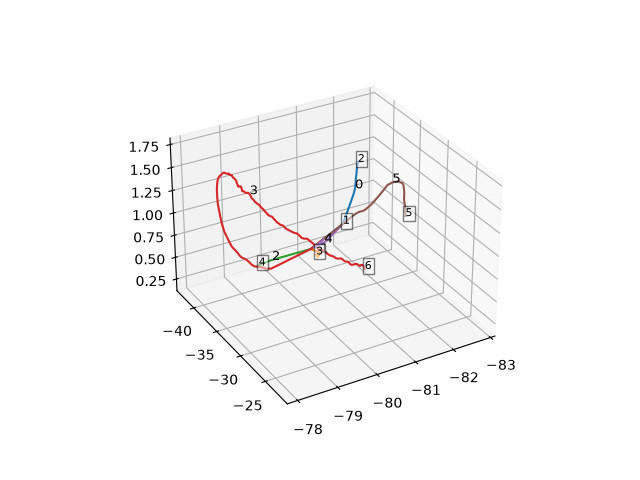

valid lines [1, 2, 3, 4, 0, 5]
[[np.int64(1), np.int64(3)], [np.int64(0), np.int64(2)], [np.int64(5)]]
[[np.int32(2), np.int32(1), np.int32(6)], [np.int32(3), np.int32(1), np.int32(4)], [np.int32(1), np.int32(5)]]
valid lines [4]
[[np.int64(1), np.int64(3)], [np.int64(0), np.int64(2)], [np.int64(5)]]
[[np.int32(2), np.int32(1), np.int32(6)], [np.int32(3), np.int32(1), np.int32(4)], [np.int32(1), np.int32(5)]]
Fleury made no progress; forcing print of line 4 to prevent infinite loop.


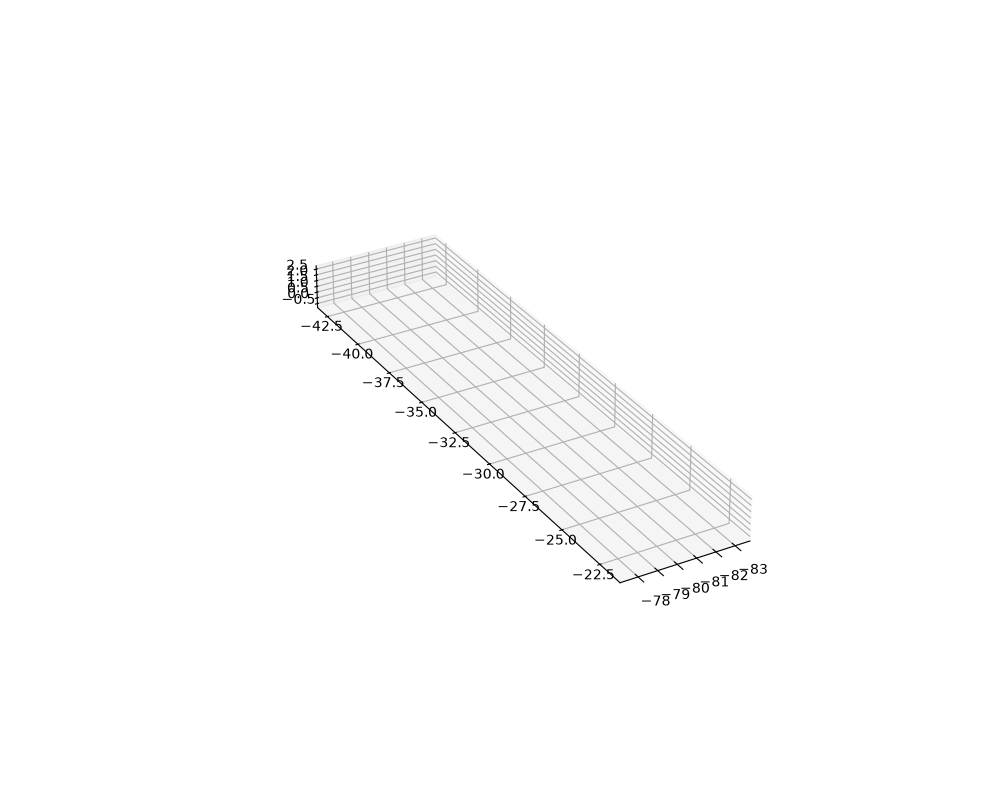

In [4]:
%matplotlib widget
from fracprint import processor_debugged as processor
from fracprint import writer_debugged as writer

# File settings
filedir = './Rhino_garv/'       # Directory of the file you're loading
filename = 'Aorta.txt'   # Name of the file you're loading
fileout = filedir + 'Aorta2.gcode'          # Name of the output file

# Print settings
d = 0.8                    # Target fibril diameter in mm
x_offset, y_offset = -80, -35  # Offset of the print from the origin                ##CALIBRATE   #changed to get back on plate
bed_temperature = 0        # Bed temperature in degrees C                       
floor = -50               # z-coord at which nozzle hits printbed in mm      ##CALIBRATE
z_min = -50                # Minimum z-coord for the print in mm              ##CALIBRATE
roof = 0                   # Height to retract printhead to at end of print
f_print = 200              # Printhead speed in mm / min
E_clean = 10                # Amount to extrude in cleaning line

# Write to file
settings = processor.build_settings(filedir, filename, fileout, d, x_offset, y_offset, bed_temperature, floor, z_min, roof, f_print, E_clean)
df, line_order_grouped = processor.shape_prep(settings)
df_print = writer.gcode_writer(df, settings, line_order_grouped)

# animation
data_frame, terminal_points, nodes = processor.node_finder(df)
eline_order, enode_order, eline_order_grouped, enode_order_grouped= processor.eulerficator(data_frame, terminal_points, nodes)

ani = processor.node_plotter(data_frame, terminal_points, eline_order, enode_order, enode_order_grouped)